In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
data = {
    'hours': [1,2,3,4,5,6,7,8,2,3],
    'attendance': [50,60,65,70,80,85,90,95,55,60],
    'marks': [40,45,50,55,65,70,80,90,48,52],
    'result': [0,0,0,1,1,1,1,1,0,0]
}

df = pd.DataFrame(data)

X = df[['hours','attendance','marks']]
y = df['result']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Single Model (Decision Tree)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0


In [6]:
# Bagging (Random Forest)

rf = RandomForestClassifier(n_estimators=10)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0


In [7]:
# Boosting (Gradient Boosting)

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 1.0


In [8]:
# Compare Results

print("DT:", accuracy_score(y_test, y_pred_dt))
print("RF:", accuracy_score(y_test, y_pred_rf))
print("GB:", accuracy_score(y_test, y_pred_gb))

DT: 1.0
RF: 1.0
GB: 1.0


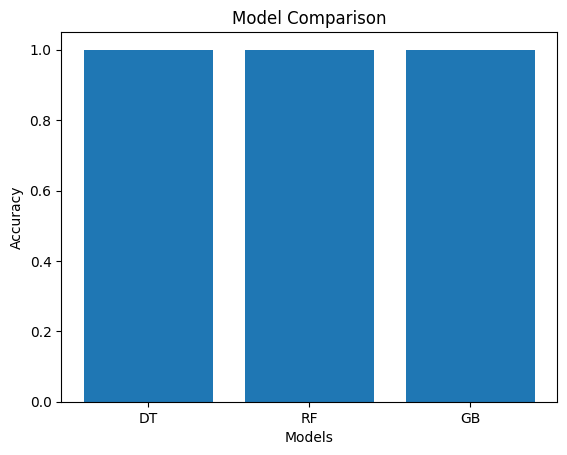

In [9]:
import matplotlib.pyplot as plt

models = ['DT','RF','GB']
scores = [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_gb)
]

plt.bar(models, scores)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [13]:
# stacking

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

In [14]:
data = {
    'hours': [1,2,3,4,5,6,7,8,2,3,4,6,7,5,3,2],
    'attendance': [50,60,65,70,80,85,90,95,55,60,75,88,92,78,66,58],
    'marks': [40,45,50,55,65,70,80,90,48,52,60,75,85,68,55,47],
    'result': [0,0,0,1,1,1,1,1,0,0,1,1,1,1,0,0]
}

df = pd.DataFrame(data)

# Features and label
X = df[['hours','attendance','marks']]
y = df['result']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [18]:
base_models = [
    ('dt', DecisionTreeClassifier()),
    ('knn', KNeighborsClassifier())
]

In [19]:
meta_model = LogisticRegression()

In [20]:
stack = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

In [21]:
stack.fit(X_train, y_train)

c:\Users\Amazon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Amazon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


,estimators,"[('dt', ...), ('knn', ...)]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2


In [23]:
y_pred = stack.predict(X_test)

In [24]:
print("Stacking Accuracy:", accuracy_score(y_test, y_pred))

Stacking Accuracy: 0.75


In [25]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.50      1.00      0.67         1

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



In [26]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
print("DT Accuracy:", accuracy_score(y_test, dt.predict(X_test)))

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
print("KNN Accuracy:", accuracy_score(y_test, knn.predict(X_test)))

DT Accuracy: 1.0
KNN Accuracy: 1.0
